# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [15]:
# Load the libraries as required.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap
import joblib

c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
# Load data


columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


fires_dt

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


# Get X and Y

Create the features data frame and target data.

In [51]:
# Separate features (X) and target (y)
X = fires_dt.drop(columns=["area"])  # Drop target variable

# Print shape to confirm
print("Target Shape:", X.shape)

X
fires_dt

Target Shape: (517, 12)


,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [49]:
y = fires_dt["area"]  # Target variable


print("Features Shape:", y.shape)

y

Features Shape: (517,)


0       0.00
1       0.00
2       0.00
3       0.00
4       0.00
       ...  
512     6.44
513    54.29
514    11.16
515     0.00
516     0.00
Name: area, Length: 517, dtype: float64

In [52]:
# Define categorical and numerical features
categorical_features = ["month", "day"]
numerical_features = ["coord_x", "coord_y", "ffmc", "dmc", "dc", "isi", "temp", "rh", "wind", "rain"]

# Log-transform the target variable to reduce skewness
fires_dt["area"] = np.log1p(fires_dt["area"])


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [53]:
preproc1 = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(), categorical_features)
])


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [54]:
preproc2 = ColumnTransformer([
    ("num", Pipeline([
        ("scaler", StandardScaler()),
        ("power", PowerTransformer(method='yeo-johnson'))
    ]), numerical_features),
    ("cat", OneHotEncoder(), categorical_features)
])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [55]:
# Define models
baseline_model = Lasso()
advanced_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

In [56]:
# Pipeline A = preproc1 + baseline
pipeline_A = Pipeline([
    ("preprocessing", preproc1),
    ("regressor", baseline_model)
])


In [57]:
# Pipeline B = preproc2 + baseline
pipeline_B = Pipeline([
    ("preprocessing", preproc2),
    ("regressor", baseline_model)
])


In [58]:
# Pipeline C = preproc1 + advanced model
pipeline_C = Pipeline([
    ("preprocessing", preproc1),
    ("regressor", advanced_model)
])

In [59]:
# Pipeline D = preproc2 + advanced model
pipeline_D = Pipeline([
    ("preprocessing", preproc2),
    ("regressor", advanced_model)
])

    

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [60]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
param_grid_baseline = {"regressor__alpha": [0.001, 0.01, 0.1, 1, 10]}
baseline_grid_A = GridSearchCV(pipeline_A, param_grid_baseline, scoring='neg_mean_squared_error', cv=5)

baseline_grid_A.fit(X_train, y_train)

c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.177e+04, tolerance: 7.234e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.125e+05, tolerance: 8.391e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', Lasso())]),
             param_grid={'regressor__alpha': [0.001, 0.01, 0.1, 1, 10]},
             scoring='neg_mean_squared_error')

In [62]:
baseline_grid_B = GridSearchCV(pipeline_B, param_grid_baseline, scoring='neg_mean_squared_error', cv=5)
baseline_grid_B.fit(X_train, y_train)

c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.312e+02, tolerance: 7.991e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_cal

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler()),
                                                                                         ('power',
                                                                                          PowerTransformer())]),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', Lasso())]),
             param_grid={'regressor__alpha': [0.001, 0.01, 0.1, 1, 10]},
             scoring='neg_mean_squared_error')

In [63]:
param_grid_advanced = {"regressor__n_estimators": [50, 100, 200], "regressor__learning_rate": [0.01, 0.1, 0.2]}
advanced_grid_C = GridSearchCV(pipeline_C, param_grid_advanced, scoring='neg_mean_squared_error', cv=5)
advanced_grid_C.fit(X_train, y_train)

c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 380, in _score
    y_pred = method_caller(
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor',
                                        GradientBoostingRegressor(random_state=42))]),
             param_grid={'regressor__learning_rate': [0.01, 0.1, 0.2],
                         'regressor__n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

In [64]:
advanced_grid_D = GridSearchCV(pipeline_D, param_grid_advanced, scoring='neg_mean_squared_error', cv=5)
advanced_grid_D.fit(X_train, y_train)


c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 380, in _score
    y_pred = method_caller(
  File "c:\Users\happy\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler()),
                                                                                         ('power',
                                                                                          PowerTransformer())]),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor',
                                        GradientBoostingRegressor(random_state=42))]),
             param_grid={'regressor__learning_rate': [0.01, 0.1, 0.2],
                         'regressor__n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

# Evaluate

+ Which model has the best performance?

In [105]:
# Evaluate models
best_baseline_A = baseline_grid_A.best_estimator_
best_baseline_B = baseline_grid_B.best_estimator_
best_advanced_C = advanced_grid_C.best_estimator_
best_advanced_D = advanced_grid_D.best_estimator_

baseline_rmse_A = np.sqrt(mean_squared_error(y_test, best_baseline_A.predict(X_test)))
baseline_mae_A = mean_absolute_error(y_test, best_baseline_A.predict(X_test))

baseline_rmse_B = np.sqrt(mean_squared_error(y_test, best_baseline_B.predict(X_test)))
baseline_mae_B = mean_absolute_error(y_test, best_baseline_B.predict(X_test))

advanced_rmse_C = np.sqrt(mean_squared_error(y_test, best_advanced_C.predict(X_test)))
advanced_mae_C = mean_absolute_error(y_test, best_advanced_C.predict(X_test))

advanced_rmse_D = np.sqrt(mean_squared_error(y_test, best_advanced_D.predict(X_test)))
advanced_mae_D = mean_absolute_error(y_test, best_advanced_D.predict(X_test))

results = {
    "Pipeline A (preproc1 + Lasso)": {"RMSE": baseline_rmse_A, "MAE": baseline_mae_A},
    "Pipeline B (preproc2 + Lasso)": {"RMSE": baseline_rmse_B, "MAE": baseline_mae_B},
    "Pipeline C (preproc1 + Gradient Boosting)": {"RMSE": advanced_rmse_C, "MAE": advanced_mae_C},
    "Pipeline D (preproc2 + Gradient Boosting)": {"RMSE": advanced_rmse_D, "MAE": advanced_mae_D}
}

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

# Select best model
best_model_name = results_df["RMSE"].idxmin()
#best_model = eval(f"best_{best_model_name.split(' ')[1].lower()}_{best_model_name.split(' ')[0][-1]}")

print(f"Best Model Selected: {best_model_name}")

                                                 RMSE        MAE
Pipeline A (preproc1 + Lasso)              107.770712  24.522374
Pipeline B (preproc2 + Lasso)              107.317464  25.077377
Pipeline C (preproc1 + Gradient Boosting)  109.144904  24.413918
Pipeline D (preproc2 + Gradient Boosting)  109.146741  24.443817
Best Model Selected: Pipeline B (preproc2 + Lasso)


In [106]:
# Select best model
best_model_name = results_df["RMSE"].idxmin()
best_model = {
    'Pipeline A (preproc1 + Lasso)': best_baseline_A,
    'Pipeline B (preproc2 + Lasso)': best_baseline_B,
    'Pipeline C (preproc1 + Gradient Boosting)': best_advanced_C,
    'Pipeline D (preproc2 + Gradient Boosting)': best_advanced_D
}[best_model_name]

print(f"Best Model Selected: {best_model_name}")

Best Model Selected: Pipeline B (preproc2 + Lasso)


# Export

+ Save the best performing model to a pickle file.

In [107]:
# Save the best model
joblib.dump(best_model, "best_forest_fire_model.pkl")

['best_forest_fire_model.pkl']

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [108]:

# Explain best model using SHAP
best_model.fit(X_train, y_train)
X_train_transformed = best_model.named_steps["preprocessing"].transform(X_train)
X_test_transformed = best_model.named_steps["preprocessing"].transform(X_test)
explainer = shap.Explainer(best_model.named_steps["regressor"], X_train_transformed)
shap_values = explainer(X_test_transformed)


IndexError: index 12 is out of bounds for axis 0 with size 12

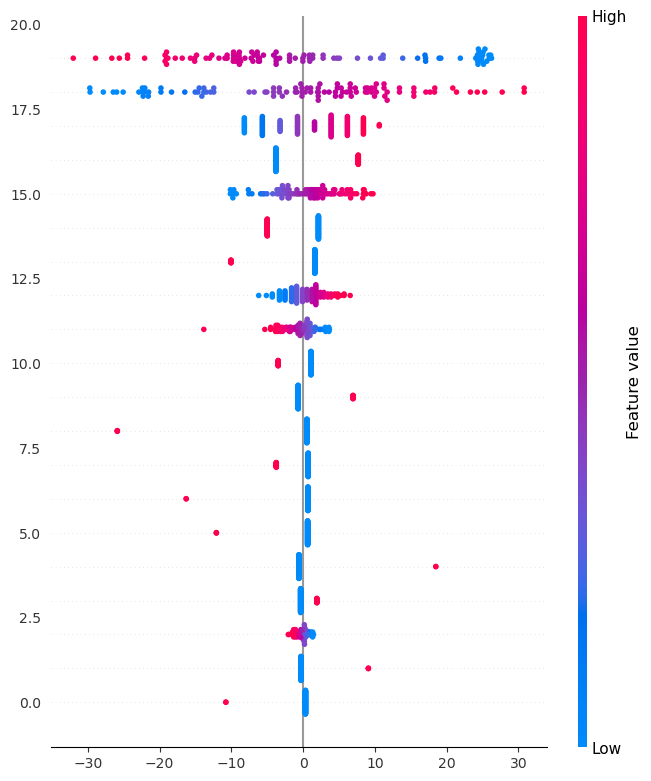

In [109]:
# Explain a single observation
observation_idx = 0
shap_values_single = explainer(X_test_transformed[observation_idx].reshape(1, -1))
shap.force_plot(
    explainer.expected_value, 
    shap_values_single.values[0], 
    features=X_test_transformed[observation_idx], 
    feature_names=X.columns
)


# Summary plot for feature importance
shap.summary_plot(shap_values, features=X_test_transformed, feature_names=X.columns)


*(Answer here.)*

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.